In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

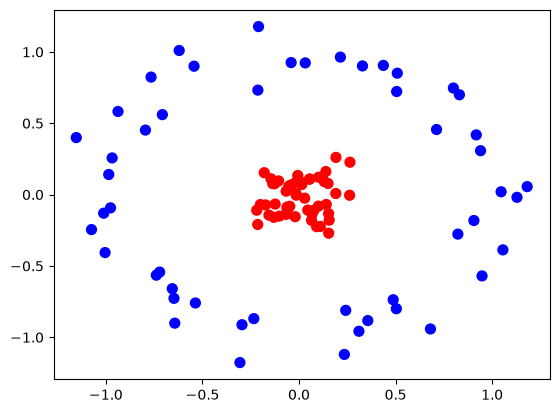

In [7]:
from sklearn.datasets import make_circles
X,y=make_circles(100,factor=.1,noise=.1)
plt.scatter(X[:,0],X[:,1],c=y,s=50,cmap='bwr')

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

In [9]:
classifier = SVC(kernel="linear")
classifier.fit(X_train, y_train.ravel())
y_pred = classifier.predict(X_test)

In [10]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.55

In [11]:
zero_one_colourmap = ListedColormap(('blue', 'red'))
def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, 
                                 stop = X_set[:, 0].max() + 1, 
                                 step = 0.01),
                       np.arange(start = X_set[:, 1].min() - 1, 
                                 stop = X_set[:, 1].max() + 1, 
                                 step = 0.01))
  
    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(), 
                                             X2.ravel()]).T).reshape(X1.shape),
               alpha = 0.75, 
               cmap = zero_one_colourmap)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = (zero_one_colourmap)(i), label = j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

C:\Users\shrey\AppData\Local\Temp\ipykernel_21780\3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


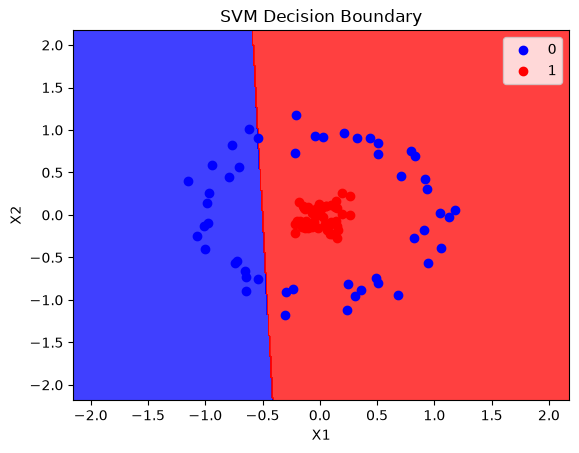

In [12]:
plot_decision_boundary(X,y,classifier)

In [14]:
def plot_3d_plot(X,y):
    r=np.exp(-(X**2).sum(1))
    ax=plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

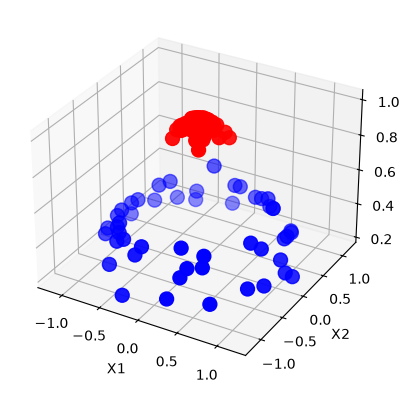

In [15]:
plot_3d_plot(X,y)

In [16]:
rbf_classifier = SVC(kernel="rbf")
rbf_classifier.fit(X_train, y_train)
y_pred = rbf_classifier.predict(X_test)

In [17]:
accuracy_score(y_test, y_pred)

1.0

C:\Users\shrey\AppData\Local\Temp\ipykernel_21780\3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


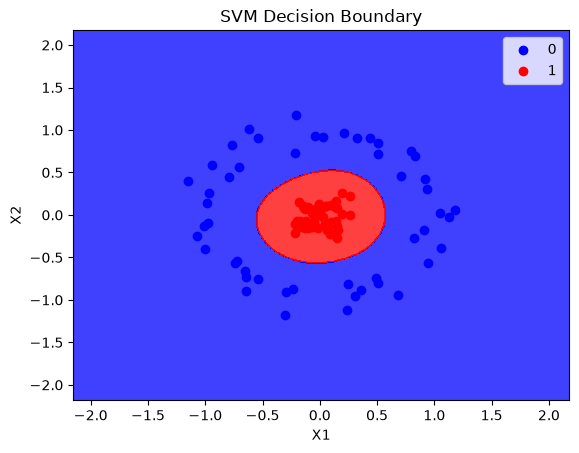

In [18]:
plot_decision_boundary(X, y, rbf_classifier)

In [19]:
poly_classifier = SVC(kernel="poly",degree=2)
poly_classifier.fit(X_train, y_train)
y_pred = poly_classifier.predict(X_test)

In [20]:
accuracy_score(y_test, y_pred)

1.0

C:\Users\shrey\AppData\Local\Temp\ipykernel_21780\3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


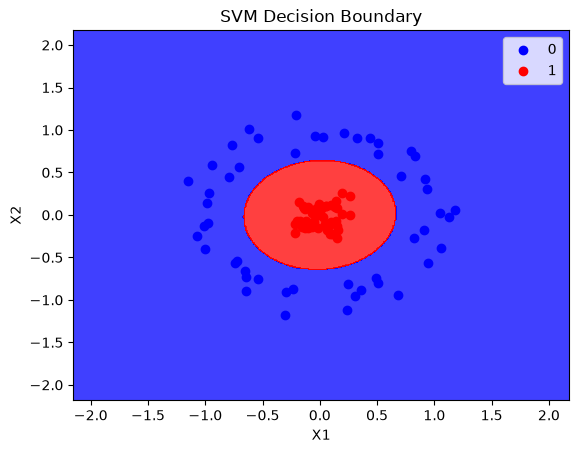

In [21]:
plot_decision_boundary(X, y, poly_classifier)

In [22]:
X

array([[-0.17984704,  0.15358924],
       [-0.0406837 ,  0.92525141],
       [-0.72145664, -0.54305233],
       [-0.12691438,  0.0755768 ],
       [ 0.14112907, -0.06899881],
       [ 0.31018074, -0.95774802],
       [ 0.83037171,  0.69964116],
       [ 0.19047588,  0.00783888],
       [ 0.07701141, -0.10969253],
       [-0.76582584,  0.82357085],
       [-0.98490553,  0.14089102],
       [ 0.15317733, -0.13306176],
       [-0.79500877,  0.45219522],
       [ 0.05593398,  0.10905701],
       [-0.12345638, -0.06655431],
       [-0.04847914,  0.06281053],
       [-1.07417458, -0.24511241],
       [-0.01985298, -0.15494601],
       [ 0.26204714, -0.00461611],
       [-0.20953259,  1.17743003],
       [-0.1300431 , -0.15913264],
       [-0.53635292, -0.75951292],
       [ 0.50385437, -0.79970324],
       [-0.21880488, -0.10953313],
       [ 0.00405222,  0.09295916],
       [ 0.15039594,  0.07791831],
       [ 0.10041734, -0.08075587],
       [ 0.82239647, -0.27692173],
       [ 0.50882644,

In [23]:
np.exp(-(X**2)).sum(1)

array([1.94485895, 1.42316602, 1.33882526, 1.9783262 , 1.97553011,
       1.30787534, 1.11475246, 1.96430776, 1.98212644, 1.06377156,
       1.35941373, 1.95926022, 1.3465776 , 1.9850533 , 1.98045441,
       1.99371514, 1.25710885, 1.97588358, 1.93361463, 1.20703414,
       1.95822573, 1.31166499, 1.30333605, 1.94132656, 1.9913794 ,
       1.97158208, 1.98346673, 1.43465762, 1.25668956, 1.46103252,
       1.88261008, 1.99100978, 1.36799469, 1.97566477, 1.97502261,
       1.13010917, 1.91238849, 1.0414098 , 1.26700359, 1.23153064,
       1.33426384, 1.42551493, 1.24719566, 1.32299766, 1.27012377,
       1.35203348, 1.98209868, 1.36949045, 1.98535684, 1.89834985,
       1.41448083, 1.2794942 , 1.33946376, 1.40816387, 1.35046364,
       1.95592737, 1.21280648, 1.94438158, 1.16084046, 1.96717386,
       1.33679389, 1.96402717, 1.9848795 , 1.97480954, 1.04135878,
       1.96693812, 1.29743599, 1.30655322, 1.99499662, 1.37743819,
       1.90608233, 1.99147935, 1.10545328, 1.4165297 , 1.97657

In [24]:
X_new=np.exp(-(X**2))

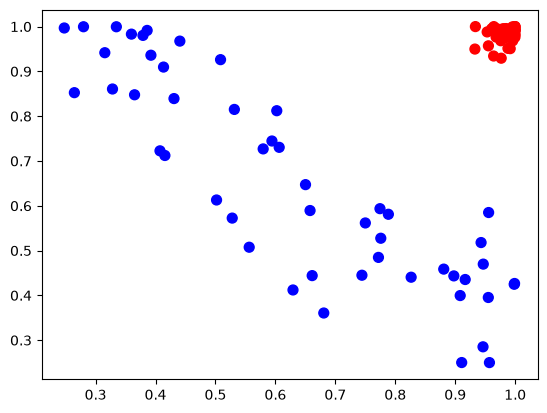

In [25]:
plt.scatter(X_new[:, 0], X_new[:, 1], c=y, s=50, cmap='bwr')